In [1]:
import pandas as pd

# Column names
columns = ['unit_number', 'time_in_cycles']

for i in range(1, 4):
    columns.append(f'op_setting_{i}')

for i in range(1, 22):
    columns.append(f'sensor_{i}')

# Load training data
train_df = pd.read_csv(
    '../data/train_FD001.txt',
    sep=r'\s+',
    header=None
)

# Remove extra empty columns
train_df = train_df.iloc[:, :26]

# Assign column names
train_df.columns = columns

# Show first rows
train_df.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
# Find maximum cycle for each engine
max_cycle = train_df.groupby(
    'unit_number'
)['time_in_cycles'].max()

# Convert to dataframe
max_cycle = max_cycle.to_frame(
    name='max_cycle'
)

# Merge with original dataframe
train_df = train_df.merge(
    max_cycle,
    on='unit_number'
)

# Calculate Remaining Useful Life
train_df['RUL'] = (
    train_df['max_cycle']
    - train_df['time_in_cycles']
)

# Show results
train_df[['unit_number',
          'time_in_cycles',
          'max_cycle',
          'RUL']].head()

,unit_number,time_in_cycles,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


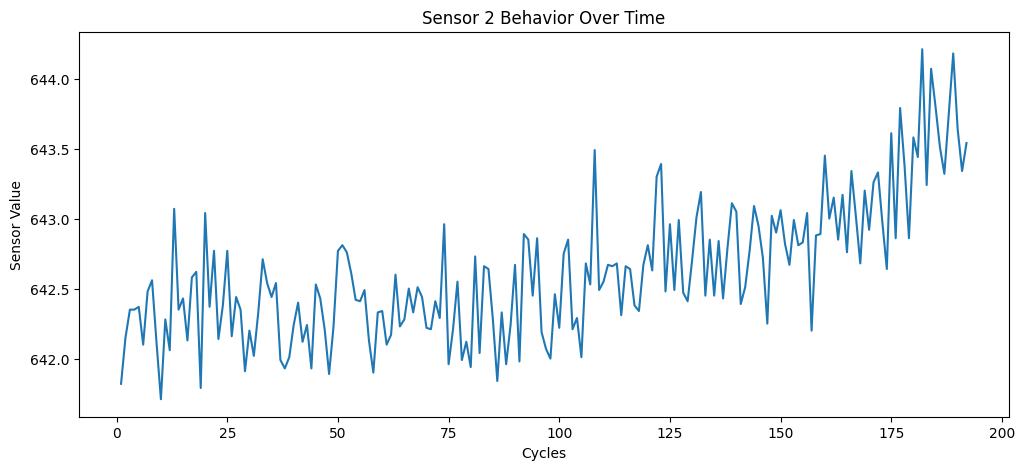

In [3]:
import matplotlib.pyplot as plt

# Select one engine
engine_1 = train_df[
    train_df['unit_number'] == 1
]

# Create figure
plt.figure(figsize=(12,5))

# Plot sensor values
plt.plot(
    engine_1['time_in_cycles'],
    engine_1['sensor_2']
)

# Labels
plt.title('Sensor 2 Behavior Over Time')
plt.xlabel('Cycles')
plt.ylabel('Sensor Value')

plt.show()

In [4]:
# Remove columns not needed for prediction
features = train_df.drop(
    columns=[
        'unit_number',
        'time_in_cycles',
        'max_cycle',
        'RUL'
    ]
)

# Target variable
target = train_df['RUL']

# Check shapes
print(features.shape)
print(target.shape)

(20631, 24)
(20631,)


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler
scaler = MinMaxScaler()

# Scale features
scaled_features = scaler.fit_transform(features)

print(scaled_features[:5])

[[0.45977011 0.16666667 0.         0.         0.18373494 0.40680183
  0.30975692 0.         1.         0.72624799 0.24242424 0.109755
  0.         0.36904762 0.63326226 0.20588235 0.1996078  0.36398615
  0.         0.33333333 0.         0.         0.71317829 0.7246617 ]
 [0.6091954  0.25       0.         0.         0.28313253 0.4530194
  0.35263336 0.         1.         0.62801932 0.21212121 0.1002423
  0.         0.38095238 0.76545842 0.27941176 0.1628135  0.41131204
  0.         0.33333333 0.         0.         0.66666667 0.73101353]
 [0.25287356 0.75       0.         0.         0.34337349 0.36952256
  0.37052667 0.         1.         0.71014493 0.27272727 0.14004308
  0.         0.25       0.79530917 0.22058824 0.17179275 0.35744517
  0.         0.16666667 0.         0.         0.62790698 0.62137531]
 [0.54022989 0.5        0.         0.         0.34337349 0.25615871
  0.33119514 0.         1.         0.74074074 0.31818182 0.12451763
  0.         0.16666667 0.8891258  0.29411765 0.1

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    scaled_features,
    target,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16504, 24)
(4127, 24)


In [7]:
from xgboost import XGBRegressor

# Create model
model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [8]:
# Predict on test data
predictions = model.predict(X_test)

print(predictions[:10])

[126.09844    10.067388  173.33553     2.3970342 132.57422   107.979164
 123.225624   94.27375    93.77809   175.4407   ]


In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Metrics
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

MAE: 29.63
RMSE: 41.36
R2 Score: 0.63


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': features.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Show top features
print(feature_importance.head(10))

      Feature  Importance
13  sensor_11    0.416568
6    sensor_4    0.166568
11   sensor_9    0.085166
14  sensor_12    0.078269
9    sensor_7    0.059595
22  sensor_20    0.033508
23  sensor_21    0.025103
19  sensor_17    0.022086
16  sensor_14    0.021825
17  sensor_15    0.020020


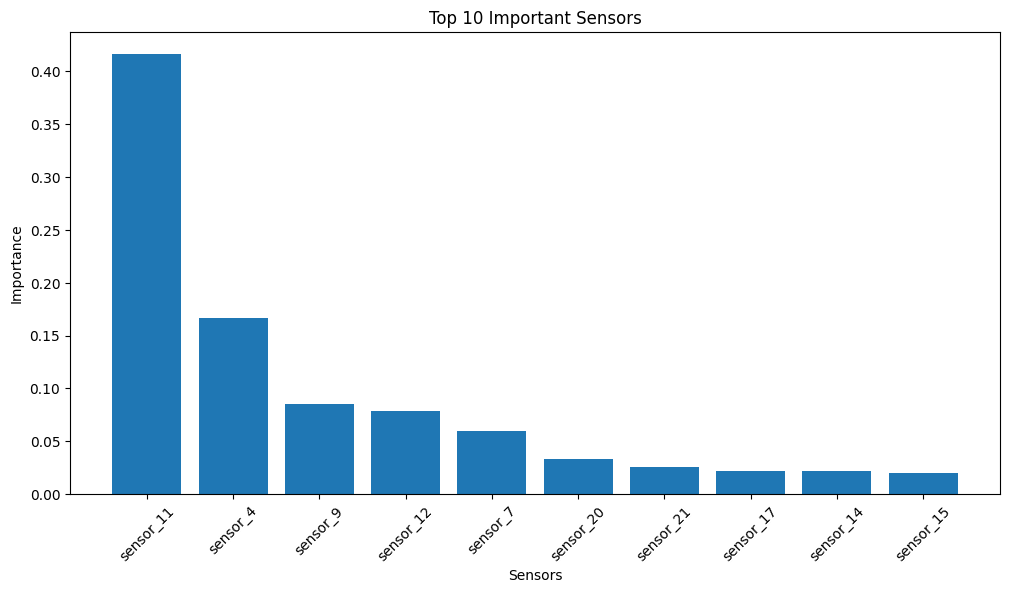

In [11]:
# Plot feature importance
plt.figure(figsize=(12,6))

plt.bar(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.xticks(rotation=45)

plt.title('Top 10 Important Sensors')
plt.xlabel('Sensors')
plt.ylabel('Importance')

plt.show()

In [14]:
# Create rolling mean features
train_df['sensor_2_rolling_mean'] = (
    train_df.groupby('unit_number')['sensor_2']
    .transform(lambda x: x.rolling(window=5).mean())
)

train_df['sensor_3_rolling_mean'] = (
    train_df.groupby('unit_number')['sensor_3']
    .transform(lambda x: x.rolling(window=5).mean())
)

# Fill missing values
train_df.bfill(inplace=True)

# Show dataframe
train_df.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL,sensor_2_rolling_mean,sensor_3_rolling_mean
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,0.03,392,2388,100.0,39.06,23.4190,192,191,642.208,1587.03
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,0.03,392,2388,100.0,39.00,23.4236,192,190,642.208,1587.03
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.03,390,2388,100.0,38.95,23.3442,192,189,642.208,1587.03
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.03,392,2388,100.0,38.88,23.3739,192,188,642.208,1587.03
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,0.03,393,2388,100.0,38.90,23.4044,192,187,642.208,1587.03


In [15]:
# Prepare updated features
features = train_df.drop(
    columns=[
        'unit_number',
        'time_in_cycles',
        'max_cycle',
        'RUL'
    ]
)

# Target variable
target = train_df['RUL']

print(features.shape)

(20631, 26)


In [16]:
from sklearn.preprocessing import MinMaxScaler

# Scale features
scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(features)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    scaled_features,
    target,
    test_size=0.2,
    random_state=42
)

In [18]:
from xgboost import XGBRegressor

# Improved model
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
model.fit(X_train, y_train)

print("Improved model trained successfully!")

Improved model trained successfully!


In [19]:
# Predictions
predictions = model.predict(X_test)

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Metrics
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print(f"Improved MAE: {mae:.2f}")
print(f"Improved RMSE: {rmse:.2f}")
print(f"Improved R2 Score: {r2:.2f}")

Improved MAE: 29.20
Improved RMSE: 41.05
Improved R2 Score: 0.63


In [21]:
# Use sensor features only
anomaly_features = train_df[
    [col for col in train_df.columns
     if 'sensor' in col]
]

print(anomaly_features.shape)

(20631, 23)


In [22]:
from sklearn.preprocessing import StandardScaler

# Standardize features
anomaly_scaler = StandardScaler()

scaled_anomaly_features = (
    anomaly_scaler.fit_transform(
        anomaly_features
    )
)

In [23]:
from sklearn.ensemble import IsolationForest

# Create model
anomaly_model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

# Train model
anomaly_model.fit(
    scaled_anomaly_features
)

print("Anomaly detection model trained!")

Anomaly detection model trained!


In [24]:
# Predict anomalies
train_df['anomaly'] = anomaly_model.predict(
    scaled_anomaly_features
)

# Convert labels
train_df['anomaly'] = train_df['anomaly'].map({
    1: 0,     # Normal
    -1: 1     # Anomaly
})

# Count anomalies
print(
    train_df['anomaly'].value_counts()
)

anomaly
0    20218
1      413
Name: count, dtype: int64


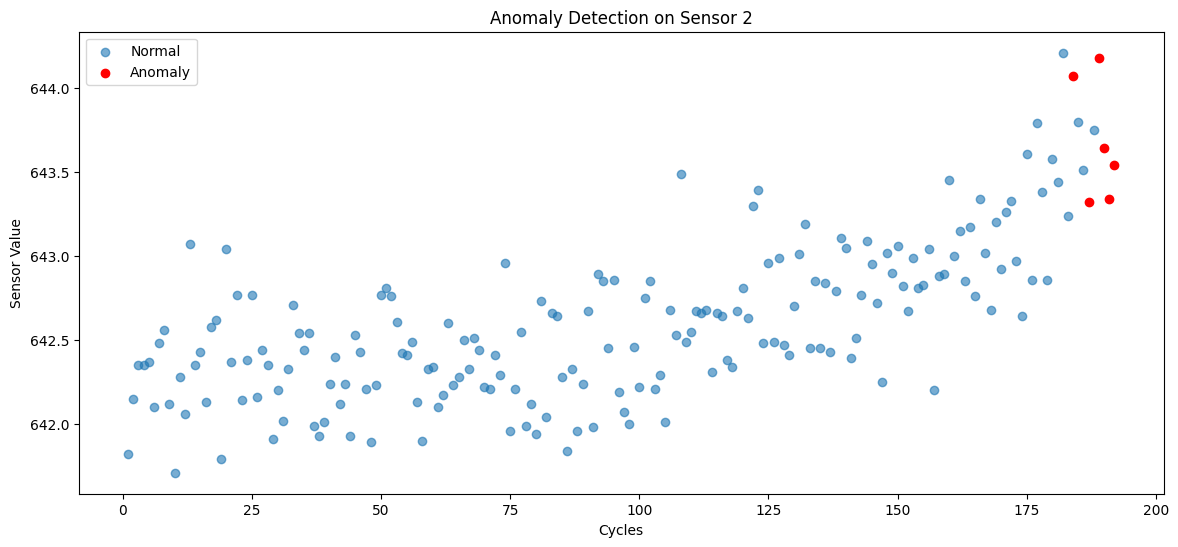

In [25]:
import matplotlib.pyplot as plt

# Select one engine
engine_1 = train_df[
    train_df['unit_number'] == 1
]

# Create figure
plt.figure(figsize=(14,6))

# Normal points
normal = engine_1[
    engine_1['anomaly'] == 0
]

plt.scatter(
    normal['time_in_cycles'],
    normal['sensor_2'],
    label='Normal',
    alpha=0.6
)

# Anomaly points
anomalies = engine_1[
    engine_1['anomaly'] == 1
]

plt.scatter(
    anomalies['time_in_cycles'],
    anomalies['sensor_2'],
    color='red',
    label='Anomaly'
)

plt.title('Anomaly Detection on Sensor 2')
plt.xlabel('Cycles')
plt.ylabel('Sensor Value')

plt.legend()

plt.show()

In [26]:
import shap

In [27]:
# Create SHAP explainer
explainer = shap.Explainer(model)

# Generate SHAP values
shap_values = explainer(X_test[:100])

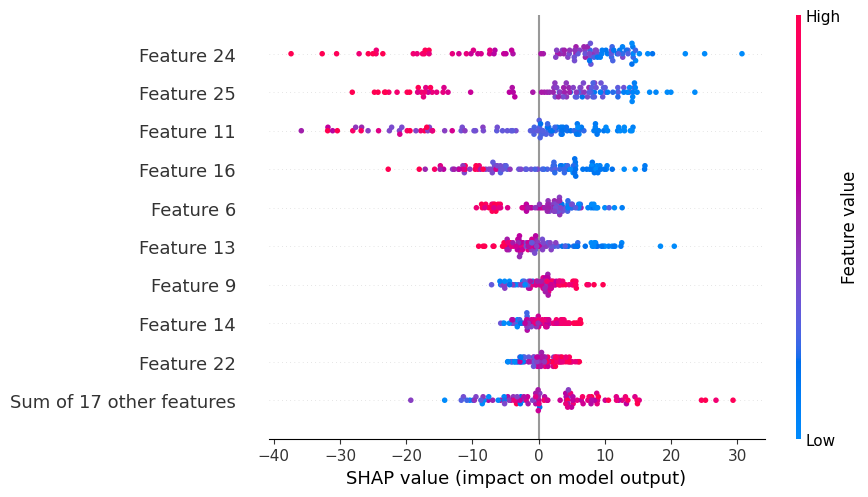

In [28]:
# SHAP summary plot
shap.plots.beeswarm(shap_values)

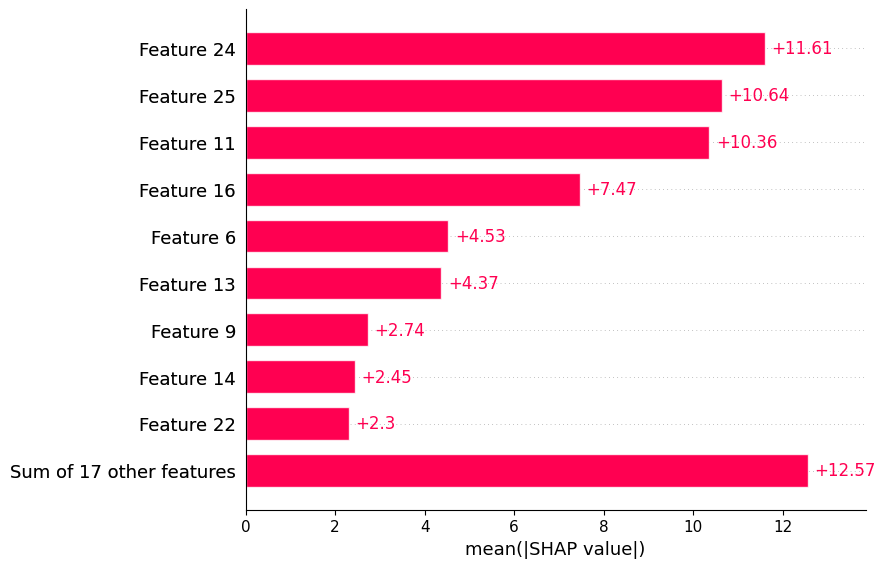

In [29]:
# Feature importance bar plot
shap.plots.bar(shap_values)